<a href="https://colab.research.google.com/github/aleks-tu/XAI4CV-Projekt/blob/main/CombinationTry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount drive, imports and downloads

In [1]:
# When loading weights from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import copy
import urllib.request
from tqdm import tqdm
from PIL import Image
from typing import Union
from pathlib import Path

# download vegetable dataset (36 classes) for finetuning
# -> https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition?resource=download
path_dataset_finetuning = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")
print("dataset path: ", path_dataset_finetuning)

dataset path:  /kaggle/input/fruit-and-vegetable-image-recognition


# Get resnet50 base model

In [3]:
# Load transformations
# -> https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
weights = models.ResNet50_Weights.IMAGENET1K_V2
transform = weights.transforms()

# Define base model
base_model = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


# Finetune resnet50 with vegetable dataset

In [ ]:
# ----------------------------
# Data Preparation
# ----------------------------

# Define the transformation
# transform = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

# Define a specific image loader to deal with images containing transparent pixels (Make them white)
from PIL import Image
from typing import Union
from pathlib import Path
# def rgba_pil_loader(path: Union[str, Path]) -> Image.Image:
#   # open path as file to avoid ResourceWarning (https://github.com/python-pillow/Pillow/issues/835)

#   # Some images are corrupt
#   corrupt_images_replacement = {
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/bell pepper/Image_56.jpg": "/kaggle/input/fruit-and-vegetable-image-recognition/train/bell pepper/Image_55.jpg",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/potato/Image_69.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/potato/Image_68.png",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/carrot/Image_68.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/carrot/Image_67.png",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/soy beans/Image_13.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/soy beans/Image_12.png",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/paprika/Image_26.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/paprika/Image_25.png",
#   }

#   with open(path, "rb") as f:
#       img = Image.open(f)
#       if (img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info)) and len(img.split())>3:
#       #   print("TRANSPARENT!")
#       #   alpha = img.convert("RGBA").split()[-1]
#       #   print("Converted")
#       #   bg = Image.new("RGB", img.size, (255, 255, 255))
#       #   print("made bg")
#       #   bg.paste(img, mask=alpha)
#       #   print("pasted img")
#       #   return bg

#         # print("TRANSPARENT")
#         # img = img.convert("RGBA")
#         # datas = img.getdata()
#         # newData = []
#         # for item in datas:
#         #     if item[0] == 255 and item[1] == 255 and item[2] == 255:
#         #         newData.append((255, 255, 255, 0))
#         #     else:
#         #         newData.append(item)
#         # img.putdata(newData)

#         background = Image.new("RGB", img.size, (255, 255, 255))
#         # print("here")
#         print(f"length: {len(img.split())}")
#         background.paste(img, mask=img.split()[3]) # 3 is the alpha channel

#         # Print value of image at pixel 50, 50:
#         # print(img.getpixel((50, 50)))

#         # print("RETURNING MODIFIED IMG")
#         return img.convert('RGB')
#       elif len(img.split())<3:
#         print("CORRUPT IMAGE -------------------------")
#         print(path)
#         return Image.new("RGB", img.size, (255,255,255))
#       else:
#         # print("NOT TRANSPARENT")
#         return img.convert("RGB")  # Ensure all images are RGB



# # Load the data
# train_data = torchvision.datasets.ImageFolder(root="/kaggle/input/fruit-and-vegetable-image-recognition/train", loader=rgba_pil_loader, transform=transform)
# test_data = torchvision.datasets.ImageFolder(root="/kaggle/input/fruit-and-vegetable-image-recognition/validation", loader=rgba_pil_loader, transform=transform)

# Load the data
train_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/train", transform=transform)
test_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/validation", transform=transform)

# Define the dataloaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# ----------------------------
# Modify Finetuned Model
# ----------------------------

# Define the model
finetuned_model = copy.deepcopy(base_model)

# # Freeze all parameters:
# for param in finetuned_model.parameters():
#     param.requires_grad = False

# Freeze all layers but the third and fourth (last two) sequential blocks
for name, param in finetuned_model.named_parameters():
  if not ('layer4' in name or 'layer3' in name):
      param.requires_grad = False
  print(f"Training {name}: {param.requires_grad}")

# Replace the last layer
num_features = finetuned_model.fc.in_features
finetuned_model.fc = nn.Linear(num_features, len(train_data.classes))
print("---------------------------------------------")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Different classes: {train_data.classes}")

Training conv1.weight: False
Training bn1.weight: False
Training bn1.bias: False
Training layer1.0.conv1.weight: False
Training layer1.0.bn1.weight: False
Training layer1.0.bn1.bias: False
Training layer1.0.conv2.weight: False
Training layer1.0.bn2.weight: False
Training layer1.0.bn2.bias: False
Training layer1.0.conv3.weight: False
Training layer1.0.bn3.weight: False
Training layer1.0.bn3.bias: False
Training layer1.0.downsample.0.weight: False
Training layer1.0.downsample.1.weight: False
Training layer1.0.downsample.1.bias: False
Training layer1.1.conv1.weight: False
Training layer1.1.bn1.weight: False
Training layer1.1.bn1.bias: False
Training layer1.1.conv2.weight: False
Training layer1.1.bn2.weight: False
Training layer1.1.bn2.bias: False
Training layer1.1.conv3.weight: False
Training layer1.1.bn3.weight: False
Training layer1.1.bn3.bias: False
Training layer1.2.conv1.weight: False
Training layer1.2.bn1.weight: False
Training layer1.2.bn1.bias: False
Training layer1.2.conv2.weight

In [ ]:
# ----------------------------
# Prepare Training
# ----------------------------

# import warnings
# warnings.filterwarnings('ignore', '.*UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images',)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(finetuned_model.parameters(), lr=0.001, momentum=0.9)

# Move the model to the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
finetuned_model = finetuned_model.to(device)

# ----------------------------
# Train
# ----------------------------

# Define the number of epochs
num_epochs = 10

# Train the model
for epoch in range(num_epochs):
    # Train the model on the training set
    finetuned_model.train()
    train_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Move the data to the device
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = finetuned_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update the training loss
        train_loss += loss.item() * inputs.size(0)

    # Evaluate the model on the test set
    finetuned_model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            # Move the data to the device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward
            outputs = finetuned_model(inputs)
            loss = criterion(outputs, labels)

            # Update the test loss and accuracy
            test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

    # Print the training and test loss and accuracy
    train_loss /= len(train_data)
    test_loss /= len(test_data)
    test_acc = test_acc.double() / len(test_data)
    print(f"Epoch [{epoch + 1}/{num_epochs}] Train Loss: {train_loss:.4f} Test Loss: {test_loss:.4f} Test Acc: {test_acc:.4f}")

# Save weights of fintuned model
torch.save(finetuned_model.state_dict(), "fine-tuned-resnet.pt")

# Load finetuned model from saved weights

In [7]:
# Load the data [COPY]
train_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/train", transform=transform)
test_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/validation", transform=transform)

In [8]:
# ----------------------------
# Modify Finetuned Model [COPY]
# ----------------------------

# Define the model
finetuned_model = copy.deepcopy(base_model)

# # Freeze all parameters:
# for param in finetuned_model.parameters():
#     param.requires_grad = False

# Freeze all layers but the third and fourth (last two) sequential blocks
for name, param in finetuned_model.named_parameters():
  if not ('layer4' in name or 'layer3' in name):
      param.requires_grad = False
  print(f"Training {name}: {param.requires_grad}")

# Replace the last layer
num_features = finetuned_model.fc.in_features
finetuned_model.fc = nn.Linear(num_features, len(train_data.classes))
print("---------------------------------------------")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Different classes: {train_data.classes}")

Training conv1.weight: False
Training bn1.weight: False
Training bn1.bias: False
Training layer1.0.conv1.weight: False
Training layer1.0.bn1.weight: False
Training layer1.0.bn1.bias: False
Training layer1.0.conv2.weight: False
Training layer1.0.bn2.weight: False
Training layer1.0.bn2.bias: False
Training layer1.0.conv3.weight: False
Training layer1.0.bn3.weight: False
Training layer1.0.bn3.bias: False
Training layer1.0.downsample.0.weight: False
Training layer1.0.downsample.1.weight: False
Training layer1.0.downsample.1.bias: False
Training layer1.1.conv1.weight: False
Training layer1.1.bn1.weight: False
Training layer1.1.bn1.bias: False
Training layer1.1.conv2.weight: False
Training layer1.1.bn2.weight: False
Training layer1.1.bn2.bias: False
Training layer1.1.conv3.weight: False
Training layer1.1.bn3.weight: False
Training layer1.1.bn3.bias: False
Training layer1.2.conv1.weight: False
Training layer1.2.bn1.weight: False
Training layer1.2.bn1.bias: False
Training layer1.2.conv2.weight

In [9]:
# Load finetuned model from drive
finetuned_model.load_state_dict(torch.load("/content/drive/MyDrive/fine-tuned-resnet_fruits-vegetables_last_seq_block.pt"))

# Load finetuned model from drive uploaded to content/
#finetuned_model.load_state_dict(torch.load("/content/fine-tuned-resnet_fruits-vegetables.pt"))

<All keys matched successfully>

# Test base and finetuned model

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
base_model.to(device)
finetuned_model.to(device)

base_model.eval()
finetuned_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
# Methods for testing the models

# Print model input image
def show_image(img_tensor, title):
  # Remove batch dimension
  if img_tensor.dim() == 4:
    img_tensor = img_tensor.squeeze(0)

  # Clone for not modifying original image
  img_tensor = img_tensor.cpu().clone()

  # Unnormalize (for better visuals)
  mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
  std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
  img_tensor = img_tensor * std + mean

  # Convert to numpy for plotting
  img_np = img_tensor.permute(1, 2, 0).numpy()
  img_np = img_np.clip(0, 1)

  plt.imshow(img_np)
  plt.title(title)
  plt.axis('off')
  plt.show()

# Get top 5 predictions for given image of base model
def top5_predictions_base(img):
  output = base_model(img)
  probabilities = torch.nn.functional.softmax(output[0], dim=0)

  top5_probabilites, top5_category_id = torch.topk(probabilities, 5)

  # Load ImageNet class labels
  url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
  imagenet_classes = urllib.request.urlopen(url).read().decode("utf-8").splitlines()

  print("\nTop 5 predictions of base model:")
  for i in range(5):
      class_name = imagenet_classes[top5_category_id[i]]
      prob = top5_probabilites[i].item()
      #print(f"{i+1}. {class_name:20s} -> {prob:.4f}")
      print(f"{class_name} ({top5_category_id[i]})".ljust(20) + f"-> {prob:.4f}")

# Needed for class labels
train_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/train", transform=transform)

# Get top 5 predictions for given image of finetuned model
def top5_predictions_finetuned(img):
  output = finetuned_model(img)
  probabilities = torch.nn.functional.softmax(output[0], dim=0)

  top5_probabilites, top5_category_id = torch.topk(probabilities, 5)

  print("\nTop 5 predictions of finetuned model:")
  for i in range(5):
      class_name = train_data.classes[top5_category_id[i]]
      prob = top5_probabilites[i].item()
      print(f"{class_name} ({top5_category_id[i]})".ljust(20) + f"-> {prob:.4f}")

torch.Size([1, 3, 224, 224])


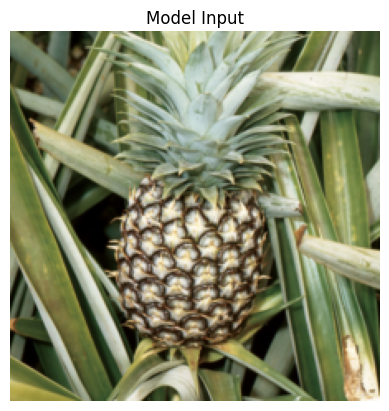


Top 5 predictions of base model:
pineapple (953)     -> 0.5330
artichoke (944)     -> 0.0016
cardoon (946)       -> 0.0016
garden spider (74)  -> 0.0009
orange (950)        -> 0.0009

Top 5 predictions of finetuned model:
pineapple (25)      -> 0.9883
corn (9)            -> 0.0009
chilli pepper (8)   -> 0.0005
soy beans (29)      -> 0.0004
sweetcorn (31)      -> 0.0004


In [27]:
img = Image.open(f'{path_dataset_finetuning}/test/pineapple/Image_10.jpg')

img = transform(img) # apply transformation to get the right format for model
img = img.unsqueeze(0) # shape 1,3,224,224 (Batch,Channel,H,W)
img = img.to(device)
print(img.shape)

# Print model input image
show_image(img, "Model Input")

# Top 5 class predictions for base and fintuned model
top5_predictions_base(img)
top5_predictions_finetuned(img)

torch.Size([1, 3, 224, 224])


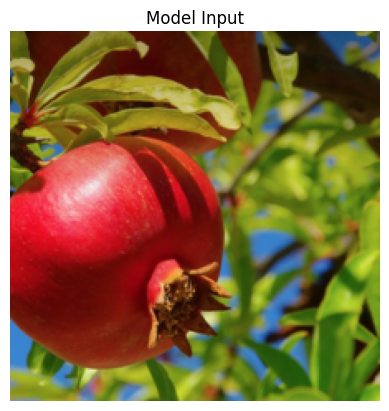


Top 5 predictions of base model:
pomegranate (957)   -> 0.5294
orange (950)        -> 0.0029
lemon (951)         -> 0.0016
custard apple (956) -> 0.0015
Granny Smith (948)  -> 0.0013

Top 5 predictions of finetuned model:
pomegranate (26)    -> 0.9812
apple (0)           -> 0.0086
mango (19)          -> 0.0019
raddish (28)        -> 0.0012
beetroot (2)        -> 0.0009


In [18]:
img = Image.open(f'{path_dataset_finetuning}/test/pomegranate/Image_4.jpg')

img = transform(img) # apply transformation to get the right format for model
img = img.unsqueeze(0) # shape 1,3,224,224 (Batch,Channel,H,W)
img = img.to(device)
print(img.shape)

# Print model input image
show_image(img, "Model Input")

# Top 5 class predictions for base and fintuned model
top5_predictions_base(img)
top5_predictions_finetuned(img)

torch.Size([1, 3, 224, 224])


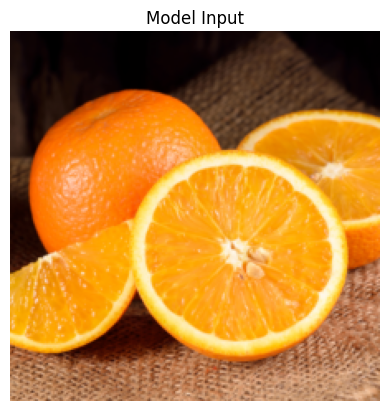


Top 5 predictions of base model:
orange (950)        -> 0.3949
lemon (951)         -> 0.0376
hognose snake (54)  -> 0.0020
cocktail shaker (503)-> 0.0015
marmot (336)        -> 0.0015

Top 5 predictions of finetuned model:
orange (21)         -> 0.9090
lemon (17)          -> 0.0872
mango (19)          -> 0.0003
kiwi (16)           -> 0.0002
cucumber (10)       -> 0.0002


In [20]:
img = Image.open(f'{path_dataset_finetuning}/test/orange/Image_8.jpeg')

img = transform(img) # apply transformation to get the right format for model
img = img.unsqueeze(0) # shape 1,3,224,224 (Batch,Channel,H,W)
img = img.to(device)
print(img.shape)

# Print model input image
show_image(img, "Model Input")

# Top 5 class predictions for base and fintuned model
top5_predictions_base(img)
top5_predictions_finetuned(img)

torch.Size([1, 3, 224, 224])


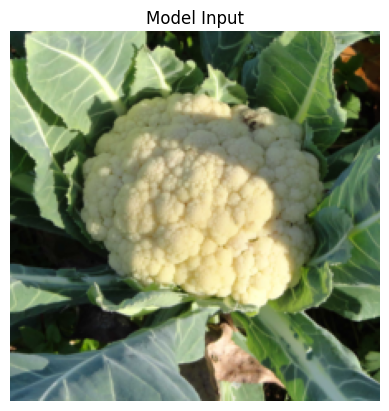


Top 5 predictions of base model:
cauliflower (938)   -> 0.5369
broccoli (937)      -> 0.0017
dough (961)         -> 0.0010
tray (868)          -> 0.0010
volcano (980)       -> 0.0009

Top 5 predictions of finetuned model:
cauliflower (7)     -> 0.9809
cabbage (4)         -> 0.0032
lettuce (18)        -> 0.0020
spinach (30)        -> 0.0010
orange (21)         -> 0.0006


In [22]:
img = Image.open(f'{path_dataset_finetuning}/test/cauliflower/Image_9.jpg')

img = transform(img) # apply transformation to get the right format for model
img = img.unsqueeze(0) # shape 1,3,224,224 (Batch,Channel,H,W)
img = img.to(device)
print(img.shape)

# Print model input image
show_image(img, "Model Input")

# Top 5 class predictions for base and fintuned model
top5_predictions_base(img)
top5_predictions_finetuned(img)

torch.Size([1, 3, 224, 224])


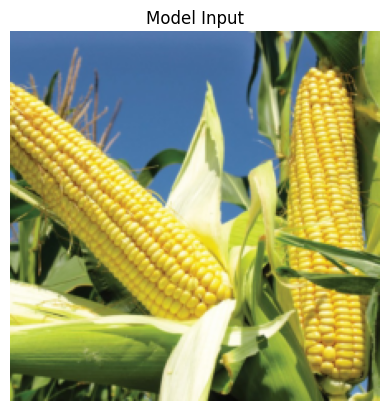


Top 5 predictions of base model:
ear (998)           -> 0.3576
corn (987)          -> 0.3070
meat loaf (962)     -> 0.0028
mashed potato (935) -> 0.0024
cucumber (943)      -> 0.0021

Top 5 predictions of finetuned model:
sweetcorn (31)      -> 0.5013
corn (9)            -> 0.4983
soy beans (29)      -> 0.0001
banana (1)          -> 0.0000
pineapple (25)      -> 0.0000


In [23]:
img = Image.open(f'{path_dataset_finetuning}/test/corn/Image_7.jpg')

img = transform(img) # apply transformation to get the right format for model
img = img.unsqueeze(0) # shape 1,3,224,224 (Batch,Channel,H,W)
img = img.to(device)
print(img.shape)

# Print model input image
show_image(img, "Model Input")

# Top 5 class predictions for base and fintuned model
top5_predictions_base(img)
top5_predictions_finetuned(img)

torch.Size([1, 3, 224, 224])


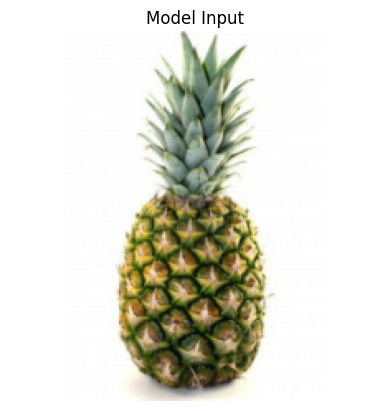


Top 5 predictions of base model:
pineapple (953)     -> 0.6093
banana (954)        -> 0.0012
table lamp (846)    -> 0.0009
rotisserie (766)    -> 0.0009
guenon (370)        -> 0.0008

Top 5 predictions of finetuned model:
pineapple (25)      -> 0.9944
corn (9)            -> 0.0002
orange (21)         -> 0.0002
pomegranate (26)    -> 0.0002
chilli pepper (8)   -> 0.0002


In [28]:
img = Image.open(f'{path_dataset_finetuning}/train/pineapple/Image_19.jpg')

img = transform(img) # apply transformation to get the right format for model
img = img.unsqueeze(0) # shape 1,3,224,224 (Batch,Channel,H,W)
img = img.to(device)
print(img.shape)

# Print model input image
show_image(img, "Model Input")

# Top 5 class predictions for base and fintuned model
top5_predictions_base(img)
top5_predictions_finetuned(img)

# Comparison of Models

## Weights

In [ ]:
def compare_model_weights(model1, model2, sort=True, exclude_layers=[]):
    weight_differences = {}
    for name, param in tqdm(model1.named_parameters(), total=161):
        # Exclude specified layers
        if any(ex_layer in name for ex_layer in exclude_layers):
            continue

        if name in model2.state_dict():
            if "conv" in name:
                for out_channel in range(param.data.size()[0]):
                  diff = torch.norm(param.data[out_channel,:,:,:] - model2.state_dict()[name].data[out_channel,:,:,:])
                  weight_differences[name+f"_c{out_channel}"] = diff.item()
            else:
                diff = torch.norm(param.data - model2.state_dict()[name].data)
                weight_differences[name] = diff.item()
        else:
            print(f"Parameter '{name}' not found in the second model")

    if sort: weight_differences = sorted(weight_differences.items(), key=lambda item: item[1], reverse=True)

    return weight_differences

print() # empty line

weight_diffs = compare_model_weights(base_model, finetuned_model, sort=True, exclude_layers=['fc'])
for name, diff in weight_diffs:
    if diff > 0:
        print(f"Weight difference for '{name}': {diff}")

100%|██████████| 161/161 [00:25<00:00,  6.28it/s]

Weight difference for 'layer4.0.downsample.0.weight': 0.7070152759552002
Weight difference for 'layer3.0.downsample.0.weight': 0.35149914026260376
Weight difference for 'layer4.1.conv2.weight_c70': 0.19096407294273376
Weight difference for 'layer4.2.conv2.weight_c309': 0.1807028204202652
Weight difference for 'layer4.0.conv2.weight_c135': 0.15494246780872345
Weight difference for 'layer4.1.conv2.weight_c415': 0.15409328043460846
Weight difference for 'layer4.2.conv1.weight_c443': 0.14386692643165588
Weight difference for 'layer4.2.conv2.weight_c208': 0.13161535561084747
Weight difference for 'layer4.2.conv2.weight_c197': 0.1224212795495987
Weight difference for 'layer4.2.bn1.weight': 0.11104483157396317
Weight difference for 'layer4.1.conv2.weight_c377': 0.10218752175569534
Weight difference for 'layer4.2.conv2.weight_c240': 0.09438575059175491
Weight difference for 'layer3.2.conv2.weight_c203': 0.09079019725322723
Weight difference for 'layer4.1.conv3.weight_c1101': 0.0906559079885482

## Attribution

In [ ]:
# # Download ImageNet labels
# !wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

# # Read the categories
# with open("imagenet_classes.txt", "r") as f:
#     labels_base = [s.strip() for s in f.readlines()]

# labels_finetuned = ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
# imagenet_classes
finetuned_classes = train_data.classes

Shape activation last layer: torch.Size([1, 2048, 7, 7])
Prediction:  wall clock
Shape gradients last layer: torch.Size([1, 2048, 7, 7])
Shape gradients last layer after GAP: torch.Size([1, 2048, 1, 1])


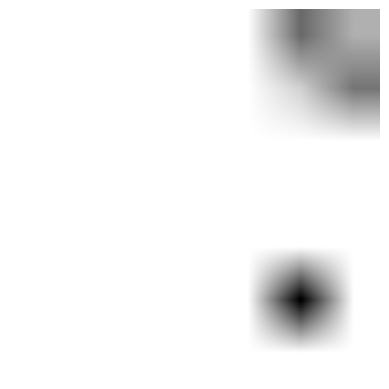

In [ ]:
def gradCAM(model, img, labels):
  # Method: Grad-CAM
  # forward and backward hooks
  activation = {}
  def get_activation(name):
      def hook(model, input, output):
          activation[name] = output.detach()
      return hook

  gradient = {}
  def get_gradient(name):
      def hook(model, input, output):
          gradient[name] = output[0].detach()
      return hook

  # register hooks at last layer
  model.layer4[2].conv3.register_forward_hook(get_activation('last_layer'))
  model.layer4[2].conv3.register_backward_hook(get_gradient('last_layer'))

  # forward pass
  img.requires_grad = True
  output = model(img)
  activation_last_layer = activation['last_layer']
  print('Shape activation last layer:', activation_last_layer.shape)

  # backward pass
  prediction = output.argmax(dim=1)
  print('Prediction: ', labels[prediction])
  prediction_output = torch.gather(output, 1, prediction.unsqueeze(-1)) # get output node at predicted index
  gradients_input = torch.autograd.grad(prediction_output, img, create_graph=False)[0] # compute gradient
  gradients_last_layer = gradient['last_layer']
  print('Shape gradients last layer:', gradients_last_layer.shape)

  # global average pooling
  gradients_last_layer = gradients_last_layer.mean(-1).mean(-1).unsqueeze(-1).unsqueeze(-1)
  print('Shape gradients last layer after GAP:', gradients_last_layer.shape)

  # Grad-CAM
  weighted_activation = activation_last_layer * gradients_last_layer
  grad_cam = torch.nn.functional.relu(weighted_activation.sum(dim=1, keepdim=True))
  up = torch.nn.Upsample(scale_factor=32, mode='bilinear')
  grad_cam = up(grad_cam)

  gradients_plot = grad_cam[0].abs().sum(dim=0).detach().cpu().numpy()
  gradients_plot = gradients_plot / gradients_plot.max()

  # plt.imshow(image)
  plt.imshow(gradients_plot, cmap='binary', vmin = 0, vmax = 1)
  # plt.imshow(gradients_plot, cmap='binary', vmin = 0, vmax = 1, alpha=0.5)
  plt.axis('off')


gradCAM(base_model, img, imagenet_classes)

## Mechanistic

In [ ]:
!pip install git+https://github.com/greentfrapp/lucent.git
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, objectives

layers = get_model_layers(base_model)
print(layers)

  Cloning https://github.com/greentfrapp/lucent.git to /tmp/pip-req-build-jyiaqjtn
  Running command git clone --filter=blob:none --quiet https://github.com/greentfrapp/lucent.git /tmp/pip-req-build-jyiaqjtn
  Resolved https://github.com/greentfrapp/lucent.git to commit 2ccc434d80097e58f53cb2a70c60f72902fe93af
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/

base model


100%|██████████| 512/512 [00:15<00:00, 33.55it/s]



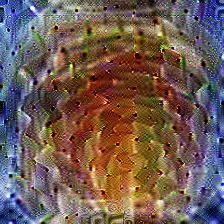

finetuned model


100%|██████████| 512/512 [00:13<00:00, 38.29it/s]



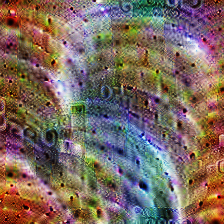

In [ ]:
from lucent.optvis import render, param, transform, objectives

layer = "layer4_2_conv3"  # layer4_0_downsample_0
channel = 10
obj = objectives.channel(layer, channel)

param_image = lambda: param.image(224, fft=True, decorrelate=True)

all_transforms = [
    transform.pad(16),
    transform.jitter(8),
    transform.random_scale([n/100. for n in range(80, 120)]),
    transform.random_rotate(list(range(-10,10)) + list(range(-5,5)) + 10*list(range(-2,2))),
    transform.jitter(2),
]

print("base model")
_ = render.render_vis(base_model, obj, param_image, transforms=all_transforms, show_inline=True)


print("finetuned model")
_ = render.render_vis(finetuned_model, obj, param_image, transforms=all_transforms, show_inline=True)

In [ ]:
def compare_models_inline(base_model, finetuned_model, layer_name, channel_indices, image_size=224):
    for channel in channel_indices:
        print(f"Visualizing layer: {layer_name}, channel: {channel}")

        obj = objectives.channel(layer_name, channel)

        # Base model
        base_vis = render.render_vis(
            base_model, obj, show_inline=False, fixed_image_size=image_size
        )[0]
        base_img = np.squeeze(base_vis)

        # Finetuned model
        fine_vis = render.render_vis(
            finetuned_model, obj, show_inline=False, fixed_image_size=image_size
        )[0]
        fine_img = np.squeeze(fine_vis)

        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        axs[0].imshow(base_img)
        axs[0].set_title("Base Model")
        axs[0].axis("off")

        axs[1].imshow(fine_img)
        axs[1].set_title("Finetuned Model")
        axs[1].axis("off")

        plt.suptitle(f"Layer: {layer_name}, Channel: {channel}")
        plt.tight_layout()
        plt.show()

In [ ]:
print(base_model.layer2[3].conv3.out_channels)

512


Visualizing layer: layer4_2_conv2, channel: 309


100%|██████████| 512/512 [00:14<00:00, 35.55it/s]


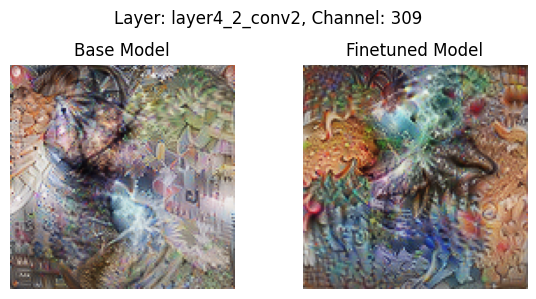

Visualizing layer: layer4_2_conv2, channel: 208


100%|██████████| 512/512 [00:14<00:00, 35.05it/s]


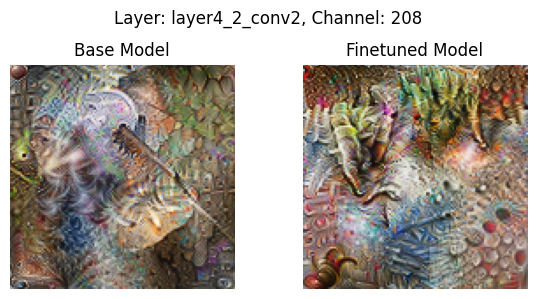

Visualizing layer: layer4_2_conv2, channel: 197


100%|██████████| 512/512 [00:14<00:00, 34.21it/s]


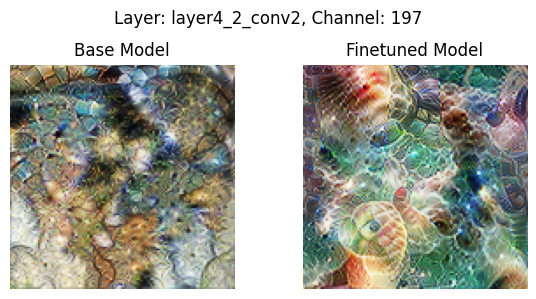

Visualizing layer: layer4_2_conv2, channel: 240


100%|██████████| 512/512 [00:14<00:00, 35.10it/s]


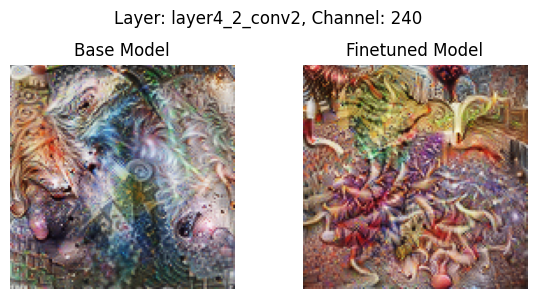

Visualizing layer: layer4_2_conv2, channel: 187


100%|██████████| 512/512 [00:15<00:00, 32.27it/s]


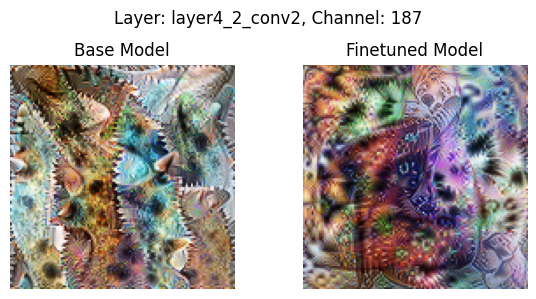

Visualizing layer: layer4_2_conv2, channel: 162


100%|██████████| 512/512 [00:14<00:00, 34.22it/s]


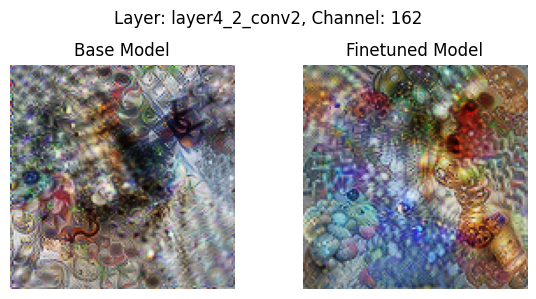

In [ ]:
channel_indices = [309, 208, 197, 240, 187, 162]
compare_models_inline(base_model, finetuned_model, "layer4_2_conv2", channel_indices)

Visualizing layer: layer4_2_conv3, channel: 1949


100%|██████████| 512/512 [00:14<00:00, 36.03it/s]


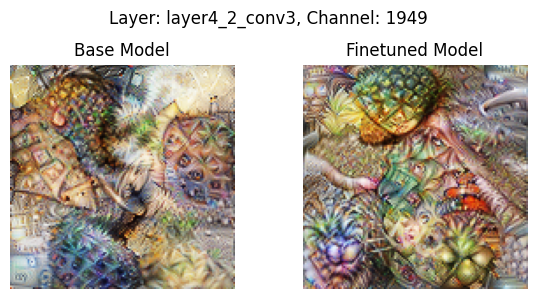

Visualizing layer: layer4_2_conv3, channel: 855


100%|██████████| 512/512 [00:14<00:00, 34.65it/s]


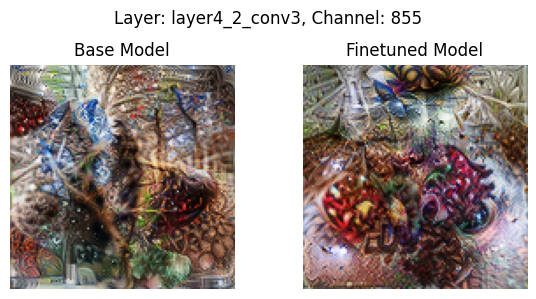

Visualizing layer: layer4_2_conv3, channel: 1124


100%|██████████| 512/512 [00:14<00:00, 35.50it/s]


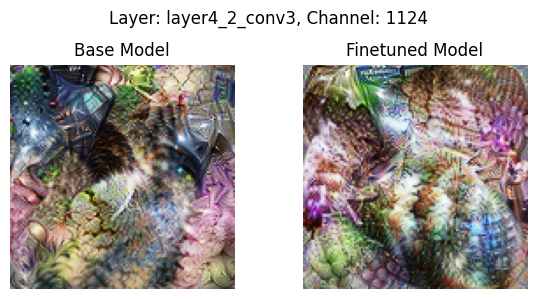

Visualizing layer: layer4_2_conv3, channel: 1427


100%|██████████| 512/512 [00:15<00:00, 32.65it/s]


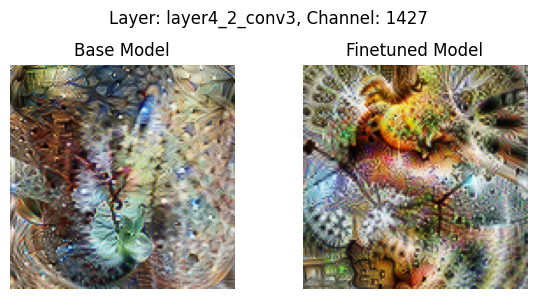

Visualizing layer: layer4_2_conv3, channel: 753


100%|██████████| 512/512 [00:14<00:00, 34.90it/s]


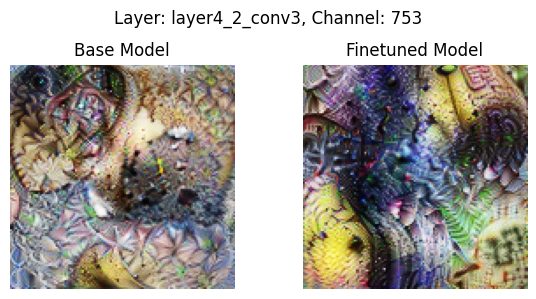

Visualizing layer: layer4_2_conv3, channel: 1953


100%|██████████| 512/512 [00:15<00:00, 32.74it/s]


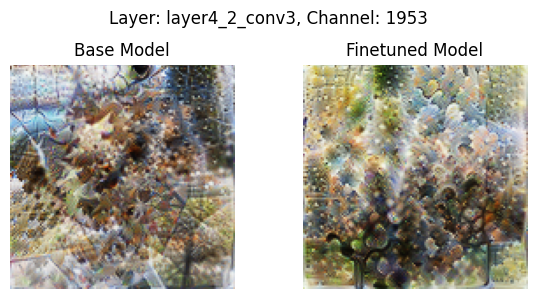

In [ ]:
channel_indices = [1949, 855, 1124, 1427, 753, 1953]
compare_models_inline(base_model, finetuned_model, "layer4_2_conv3", channel_indices)

Visualizing layer: layer2_3_conv3, channel: 0


100%|██████████| 512/512 [00:11<00:00, 44.11it/s]


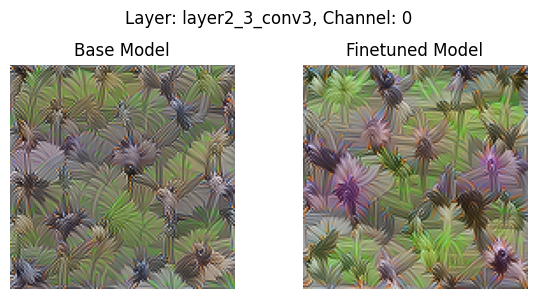

Visualizing layer: layer2_3_conv3, channel: 42


100%|██████████| 512/512 [00:11<00:00, 43.03it/s]


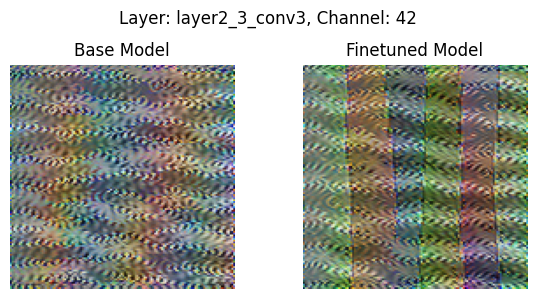

Visualizing layer: layer2_3_conv3, channel: 511


100%|██████████| 512/512 [00:11<00:00, 43.43it/s]


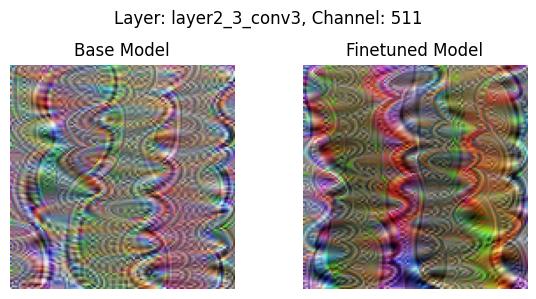

In [ ]:
# Should be very similar because layer2 is not finetuned
channel_indices = [0, 42, 511]
compare_models_inline(base_model, finetuned_model, "layer2_3_conv3", channel_indices)